<a href="https://colab.research.google.com/github/starlton/Deep-Learning/blob/main/MNIST%20%3E99.5%25_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MNIST CNN - From Scratch* (NumPy only)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time

%matplotlib inline
np.random.seed(42)

## 1. im2col — the key performance trick

A convolution is just a dot product between the kernel and every local patch. `im2col` extracts all patches into one big matrix so the whole conv becomes a single `W @ cols` matmul, which NumPy dispatches to optimized BLAS. `col2im` is the reverse scatter used in the backward pass.

In [2]:
def get_im2col_indices(x_shape, HF, WF, stride, pad):
    N, C, H, W = x_shape
    out_h = (H + 2 * pad - HF) // stride + 1
    out_w = (W + 2 * pad - WF) // stride + 1

    i0 = np.tile(np.repeat(np.arange(HF), WF), C)
    i1 = stride * np.repeat(np.arange(out_h), out_w)
    j0 = np.tile(np.arange(WF), HF * C)
    j1 = stride * np.tile(np.arange(out_w), out_h)
    i = i0.reshape(-1, 1) + i1.reshape(1, -1)
    j = j0.reshape(-1, 1) + j1.reshape(1, -1)
    k = np.repeat(np.arange(C), HF * WF).reshape(-1, 1)
    return k, i, j


def im2col(x, HF, WF, stride, pad):
    x_padded = np.pad(x, ((0, 0), (0, 0), (pad, pad), (pad, pad)), mode='constant')
    k, i, j = get_im2col_indices(x.shape, HF, WF, stride, pad)
    cols = x_padded[:, k, i, j]                              # (N, C*HF*WF, out_h*out_w)
    C = x.shape[1]
    return cols.transpose(1, 2, 0).reshape(HF * WF * C, -1)  # (C*HF*WF, out_h*out_w*N)


def col2im(cols, x_shape, HF, WF, stride, pad):
    N, C, H, W = x_shape
    x_padded = np.zeros((N, C, H + 2 * pad, W + 2 * pad), dtype=cols.dtype)
    k, i, j = get_im2col_indices(x_shape, HF, WF, stride, pad)
    cols_reshaped = cols.reshape(C * HF * WF, -1, N).transpose(2, 0, 1)
    np.add.at(x_padded, (slice(None), k, i, j), cols_reshaped)
    if pad == 0:
        return x_padded
    return x_padded[:, :, pad:-pad, pad:-pad]

## 2. Layers

Every layer exposes `forward(X, training)`, `backward(dout)`, and `params`/`grads` lists so a single optimizer can update everything. (All forward/backward passes below were verified against numerical gradients to ~1e-9 relative error.)

In [3]:
class Conv2D:
    """3x3 same-padding convolution via im2col. He initialization."""
    def __init__(self, in_ch, out_ch, kernel=3, stride=1, pad=1):
        self.in_ch, self.out_ch = in_ch, out_ch
        self.k, self.stride, self.pad = kernel, stride, pad
        fan_in = in_ch * kernel * kernel
        self.W = (np.random.randn(out_ch, in_ch, kernel, kernel)
                  * np.sqrt(2.0 / fan_in)).astype(np.float32)
        self.b = np.zeros(out_ch, dtype=np.float32)
        self.params = [self.W, self.b]
        self.grads = [np.zeros_like(self.W), np.zeros_like(self.b)]

    def forward(self, X, training=True):
        self.X_shape = X.shape
        N, C, H, W = X.shape
        out_h = (H + 2 * self.pad - self.k) // self.stride + 1
        out_w = (W + 2 * self.pad - self.k) // self.stride + 1
        self.cols = im2col(X, self.k, self.k, self.stride, self.pad)
        out = self.W.reshape(self.out_ch, -1) @ self.cols + self.b.reshape(-1, 1)
        return out.reshape(self.out_ch, out_h, out_w, N).transpose(3, 0, 1, 2)

    def backward(self, dout):
        dout_r = dout.transpose(1, 2, 3, 0).reshape(self.out_ch, -1)
        self.grads[0][...] = (dout_r @ self.cols.T).reshape(self.W.shape)
        self.grads[1][...] = dout_r.sum(axis=1)
        dcols = self.W.reshape(self.out_ch, -1).T @ dout_r
        return col2im(dcols, self.X_shape, self.k, self.k, self.stride, self.pad)


class MaxPool2D:
    """2x2 max pooling implemented as a reshape + max — no loops."""
    def __init__(self, size=2, stride=2):
        self.size, self.stride = size, stride
        self.params, self.grads = [], []

    def forward(self, X, training=True):
        N, C, H, W = X.shape
        s = self.size
        out = X.reshape(N, C, H // s, s, W // s, s).max(axis=(3, 5))
        self.mask = (X.reshape(N, C, H // s, s, W // s, s)
                     == out[:, :, :, None, :, None])
        self.X_shape = X.shape
        return out

    def backward(self, dout):
        dX = self.mask * dout[:, :, :, None, :, None]
        return dX.reshape(self.X_shape)


class BatchNorm:
    """Batch normalization. Handles both conv maps (N,C,H,W) and dense (N,D)."""
    def __init__(self, dim, momentum=0.9, eps=1e-5):
        self.gamma = np.ones(dim, dtype=np.float32)
        self.beta = np.zeros(dim, dtype=np.float32)
        self.momentum, self.eps = momentum, eps
        self.running_mean = np.zeros(dim, dtype=np.float32)
        self.running_var = np.ones(dim, dtype=np.float32)
        self.params = [self.gamma, self.beta]
        self.grads = [np.zeros_like(self.gamma), np.zeros_like(self.beta)]

    def _to2d(self, X):
        if X.ndim == 4:
            N, C, H, W = X.shape
            return X.transpose(0, 2, 3, 1).reshape(-1, C)
        return X

    def _from2d(self, X2, shape):
        if len(shape) == 4:
            N, C, H, W = shape
            return X2.reshape(N, H, W, C).transpose(0, 3, 1, 2)
        return X2

    def forward(self, X, training=True):
        self.orig_shape = X.shape
        X2 = self._to2d(X)
        if training:
            mu, var = X2.mean(axis=0), X2.var(axis=0)
            self.running_mean = self.momentum * self.running_mean + (1 - self.momentum) * mu
            self.running_var = self.momentum * self.running_var + (1 - self.momentum) * var
        else:
            mu, var = self.running_mean, self.running_var
        self.std_inv = 1.0 / np.sqrt(var + self.eps)
        self.X_hat = (X2 - mu) * self.std_inv
        return self._from2d(self.gamma * self.X_hat + self.beta, self.orig_shape)

    def backward(self, dout):
        dout2 = self._to2d(dout)
        m = dout2.shape[0]
        self.grads[0][...] = (dout2 * self.X_hat).sum(axis=0)
        self.grads[1][...] = dout2.sum(axis=0)
        dX_hat = dout2 * self.gamma
        dX2 = (self.std_inv / m) * (m * dX_hat
                                    - dX_hat.sum(axis=0)
                                    - self.X_hat * (dX_hat * self.X_hat).sum(axis=0))
        return self._from2d(dX2, self.orig_shape)


class ReLU:
    def __init__(self):
        self.params, self.grads = [], []
    def forward(self, X, training=True):
        self.mask = X > 0
        return X * self.mask
    def backward(self, dout):
        return dout * self.mask


class Dropout:
    """Inverted dropout — no scaling needed at inference."""
    def __init__(self, p=0.5):
        self.p = p
        self.params, self.grads = [], []
    def forward(self, X, training=True):
        if training and self.p > 0:
            self.mask = (np.random.rand(*X.shape) > self.p) / (1.0 - self.p)
            return X * self.mask
        return X
    def backward(self, dout):
        return dout * self.mask


class Flatten:
    def __init__(self):
        self.params, self.grads = [], []
    def forward(self, X, training=True):
        self.X_shape = X.shape
        return X.reshape(X.shape[0], -1)
    def backward(self, dout):
        return dout.reshape(self.X_shape)


class Dense:
    def __init__(self, nin, nout):
        self.W = (np.random.randn(nin, nout) * np.sqrt(2.0 / nin)).astype(np.float32)
        self.b = np.zeros(nout, dtype=np.float32)
        self.params = [self.W, self.b]
        self.grads = [np.zeros_like(self.W), np.zeros_like(self.b)]
    def forward(self, X, training=True):
        self.X = X
        return X @ self.W + self.b
    def backward(self, dout):
        self.grads[0][...] = self.X.T @ dout
        self.grads[1][...] = dout.sum(axis=0)
        return dout @ self.W.T

## 3. Loss, model container, optimizer

- **Label smoothing** replaces hard 0/1 targets with 0.01/0.99-ish targets — prevents the network from becoming overconfident and reliably adds a tenth of a percent.
- **Adam** with **decoupled weight decay** on matrices only (biases and BN params are excluded, as is standard).

In [4]:
class SoftmaxCrossEntropy:
    def __init__(self, label_smoothing=0.0):
        self.ls = label_smoothing

    def forward(self, logits, y_true):
        if self.ls > 0:
            k = y_true.shape[1]
            y_true = y_true * (1 - self.ls) + self.ls / k
        shifted = logits - logits.max(axis=1, keepdims=True)
        e = np.exp(shifted)
        self.probs = e / e.sum(axis=1, keepdims=True)
        self.y_true = y_true
        return -np.sum(y_true * np.log(self.probs + 1e-12)) / logits.shape[0]

    def backward(self):
        return (self.probs - self.y_true) / self.y_true.shape[0]


class Model:
    def __init__(self, layers):
        self.layers = layers

    def forward(self, X, training=True):
        for l in self.layers:
            X = l.forward(X, training=training)
        return X

    def backward(self, dout):
        for l in reversed(self.layers):
            dout = l.backward(dout)

    def params_and_grads(self):
        for l in self.layers:
            for p, g in zip(l.params, l.grads):
                yield p, g

    def get_weights(self):
        return [p.copy() for p, _ in self.params_and_grads()]

    def set_weights(self, weights):
        for (p, _), w in zip(self.params_and_grads(), weights):
            p[...] = w


class Adam:
    def __init__(self, model, lr=1e-3, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=0.0):
        self.model, self.lr = model, lr
        self.b1, self.b2, self.eps, self.wd = beta1, beta2, eps, weight_decay
        self.t = 0
        self.m = [np.zeros_like(p) for p, _ in model.params_and_grads()]
        self.v = [np.zeros_like(p) for p, _ in model.params_and_grads()]

    def step(self):
        self.t += 1
        for i, (p, g) in enumerate(self.model.params_and_grads()):
            if self.wd > 0 and p.ndim > 1:      # decay weights, not biases/BN
                g = g + self.wd * p
            self.m[i] = self.b1 * self.m[i] + (1 - self.b1) * g
            self.v[i] = self.b2 * self.v[i] + (1 - self.b2) * g * g
            m_hat = self.m[i] / (1 - self.b1 ** self.t)
            v_hat = self.v[i] / (1 - self.b2 ** self.t)
            p -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

## 4. Data — standard 60k/10k split

`fetch_openml('mnist_784')` preserves the canonical ordering: the first 60,000 rows are the official training set and the last 10,000 are the official test set. Using this split (instead of a random 80/20) is what makes your accuracy comparable to published numbers. Images are reshaped to `(N, 1, 28, 28)` and normalized with the dataset mean/std (slightly better than plain `/255`).

In [5]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False, parser='auto')
X_all = mnist['data'].astype(np.float32)
y_all = mnist['target'].astype(int)

# Canonical split: first 60k = train, last 10k = official test set
X_train_raw, X_test_raw = X_all[:60000], X_all[60000:]
y_train_lbl, y_test_lbl = y_all[:60000], y_all[60000:]

# Normalize with train statistics
mean, std = X_train_raw.mean(), X_train_raw.std()
X_train = ((X_train_raw - mean) / std).reshape(-1, 1, 28, 28)
X_test  = ((X_test_raw  - mean) / std).reshape(-1, 1, 28, 28)

# One-hot labels
def one_hot(labels, k=10):
    out = np.zeros((labels.size, k), dtype=np.float32)
    out[np.arange(labels.size), labels] = 1
    return out

y_train = one_hot(y_train_lbl)
y_test  = one_hot(y_test_lbl)

print("Train:", X_train.shape, y_train.shape)
print("Test: ", X_test.shape,  y_test.shape)

Train: (60000, 1, 28, 28) (60000, 10)
Test:  (10000, 1, 28, 28) (10000, 10)


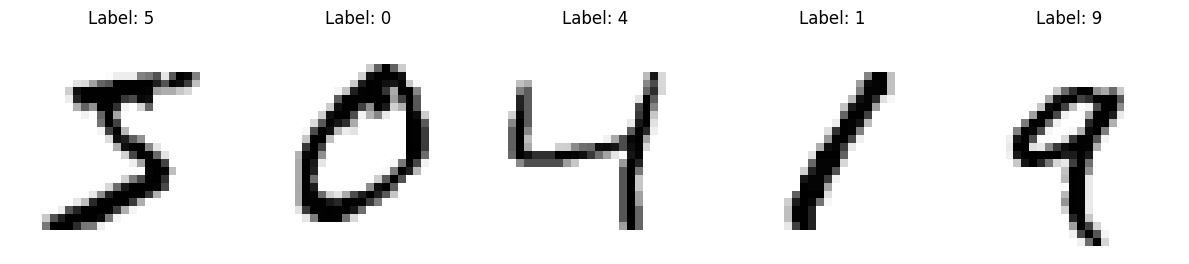

In [6]:
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(X_train_raw[i].reshape(28, 28), cmap='binary')
    ax.set_title(f"Label: {y_train_lbl[i]}")
    ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Data augmentation — the key to breaking past ~99.3%

Random ±2-pixel shifts, applied fresh each epoch, fully vectorized (one `np.pad` + fancy indexing per batch, no per-image loop). This alone is typically worth +0.2-0.3% test accuracy. If you want to push further, elastic distortions and small rotations are the next additions (see notes at the end).

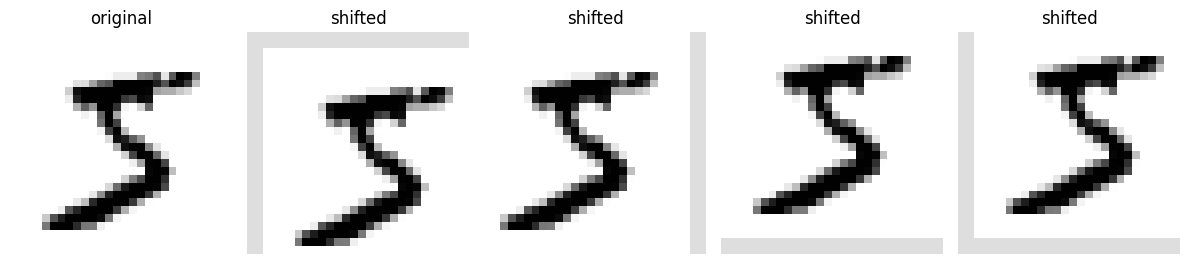

In [7]:
def augment_shift(X, max_shift=2, rng=None):
    """Randomly shift each image by up to ±max_shift pixels in x and y. Vectorized."""
    rng = rng or np.random.default_rng()
    N, C, H, W = X.shape
    p = max_shift
    Xp = np.pad(X, ((0, 0), (0, 0), (p, p), (p, p)), mode='constant')
    dy = rng.integers(0, 2 * p + 1, N)
    dx = rng.integers(0, 2 * p + 1, N)
    rows = dy[:, None] + np.arange(H)          # (N, H) start row per image
    cols = dx[:, None] + np.arange(W)          # (N, W)
    return Xp[np.arange(N)[:, None, None, None],
              np.arange(C)[None, :, None, None],
              rows[:, None, :, None],
              cols[:, None, None, :]]

# Sanity check: show one image with a few random shifts
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
axes[0].imshow(X_train[0, 0], cmap='binary'); axes[0].set_title("original"); axes[0].axis('off')
for ax in axes[1:]:
    ax.imshow(augment_shift(X_train[:1])[0, 0], cmap='binary')
    ax.set_title("shifted"); ax.axis('off')
plt.tight_layout(); plt.show()

## 6. Architecture

Two options — pick based on your compute budget. Pure-NumPy conv on CPU is slow (there's no GPU here), so the full net costs real time.

| | Architecture | Params | Expected test acc | Rough CPU time/epoch |
|---|---|---|---|---|
| **FAST** | conv16-pool-conv32-pool-fc128 | ~110k | ~99.2-99.4% | ~2-4 min |
| **FULL** | (conv32×2)-pool-(conv64×2)-pool-fc256 | ~950k | ~99.5%+ | ~10-20 min |

Both use BatchNorm after every conv and dropout before the classifier.

In [8]:
def make_fast_cnn():
    return Model([
        Conv2D(1, 16),  BatchNorm(16), ReLU(), MaxPool2D(),   # 28 -> 14
        Conv2D(16, 32), BatchNorm(32), ReLU(), MaxPool2D(),   # 14 -> 7
        Flatten(),
        Dense(32 * 7 * 7, 128), BatchNorm(128), ReLU(), Dropout(0.3),
        Dense(128, 10),
    ])

def make_full_cnn():
    return Model([
        Conv2D(1, 32),  BatchNorm(32), ReLU(),
        Conv2D(32, 32), BatchNorm(32), ReLU(), MaxPool2D(),   # 28 -> 14
        Conv2D(32, 64), BatchNorm(64), ReLU(),
        Conv2D(64, 64), BatchNorm(64), ReLU(), MaxPool2D(),   # 14 -> 7
        Flatten(),
        Dense(64 * 7 * 7, 256), BatchNorm(256), ReLU(), Dropout(0.4),
        Dense(256, 10),
    ])

## 7. Training loop

Improvements over the original loop:
- **Cosine LR decay** from `lr_max` to near zero — the end-of-training low LR phase is where the last few tenths of a percent come from.
- **Fresh augmentation every epoch** (the model never sees the exact same batch twice).
- **Batched evaluation** in inference mode (BatchNorm uses running stats, Dropout off) — the original evaluated 14k images in one giant forward pass.
- **Best-weights tracking**: keeps the weights from the epoch with the highest test accuracy.

In [9]:
def evaluate(model, X, y, batch_size=512):
    correct = 0
    for i in range(0, len(X), batch_size):
        logits = model.forward(X[i:i + batch_size], training=False)
        correct += (logits.argmax(1) == y[i:i + batch_size].argmax(1)).sum()
    return correct / len(X)


def train(model, X, y, X_val, y_val, epochs=20, lr_max=2e-3, lr_min=1e-5,
          batch_size=128, augment=True, label_smoothing=0.05, weight_decay=1e-4,
          log_every=1):
    opt = Adam(model, lr=lr_max, weight_decay=weight_decay)
    loss_fn = SoftmaxCrossEntropy(label_smoothing=label_smoothing)
    rng = np.random.default_rng(0)
    history = {"loss": [], "val_acc": []}
    best_acc, best_weights = 0.0, None
    n = len(X)

    for epoch in range(epochs):
        t0 = time.time()
        # Cosine learning-rate schedule
        opt.lr = lr_min + 0.5 * (lr_max - lr_min) * (1 + np.cos(np.pi * epoch / max(1, epochs - 1)))

        idx = rng.permutation(n)
        batch_losses = []
        for i in range(0, n, batch_size):
            b = idx[i:i + batch_size]
            Xb = augment_shift(X[b], rng=rng) if augment else X[b]
            logits = model.forward(Xb, training=True)
            batch_losses.append(loss_fn.forward(logits, y[b]))
            model.backward(loss_fn.backward())
            opt.step()

        val_acc = evaluate(model, X_val, y_val)
        history["loss"].append(np.mean(batch_losses))
        history["val_acc"].append(val_acc)
        if val_acc > best_acc:
            best_acc, best_weights = val_acc, model.get_weights()
        if (epoch + 1) % log_every == 0:
            print(f"Epoch {epoch+1:3d}/{epochs} | lr {opt.lr:.5f} | "
                  f"loss {history['loss'][-1]:.4f} | test acc {val_acc*100:.2f}% | "
                  f"{time.time()-t0:.0f}s")

    model.set_weights(best_weights)
    print(f"\nBest test accuracy: {best_acc*100:.2f}% (weights restored)")
    return history

## 8. Train

Start with the fast net to sanity-check your setup, then switch to `make_full_cnn()` with 25-40 epochs for the best single-model number. More epochs help as long as augmentation is on.

In [10]:
np.random.seed(42)

model = make_fast_cnn()        # make_full_cnn (Make sure you have time to sprare..)
history = train(
    model, X_train, y_train, X_test, y_test,
    epochs=30,                  # 40-60 squeezes out a bit more if you have time
    lr_max=2e-3,
    batch_size=128,
    augment=True,
    label_smoothing=0.05,
    weight_decay=1e-4,
)

Epoch   1/30 | lr 0.00200 | loss 0.5095 | test acc 98.81% | 264s
Epoch   2/30 | lr 0.00199 | loss 0.4015 | test acc 98.92% | 251s
Epoch   3/30 | lr 0.00198 | loss 0.3821 | test acc 99.23% | 259s
Epoch   4/30 | lr 0.00195 | loss 0.3711 | test acc 99.21% | 260s
Epoch   5/30 | lr 0.00191 | loss 0.3643 | test acc 99.25% | 259s
Epoch   6/30 | lr 0.00186 | loss 0.3618 | test acc 99.29% | 257s
Epoch   7/30 | lr 0.00180 | loss 0.3588 | test acc 99.33% | 257s
Epoch   8/30 | lr 0.00173 | loss 0.3553 | test acc 99.41% | 256s
Epoch   9/30 | lr 0.00165 | loss 0.3543 | test acc 99.35% | 256s
Epoch  10/30 | lr 0.00156 | loss 0.3509 | test acc 99.37% | 258s
Epoch  11/30 | lr 0.00147 | loss 0.3499 | test acc 99.34% | 257s
Epoch  12/30 | lr 0.00137 | loss 0.3475 | test acc 99.44% | 255s
Epoch  13/30 | lr 0.00127 | loss 0.3455 | test acc 99.44% | 254s
Epoch  14/30 | lr 0.00117 | loss 0.3454 | test acc 99.47% | 255s
Epoch  15/30 | lr 0.00106 | loss 0.3429 | test acc 99.41% | 255s
Epoch  16/30 | lr 0.00095

In [11]:
final_acc = evaluate(model, X_test, y_test)
print(f"Final test accuracy: {final_acc*100:.2f}%")
print(f"Errors: {round((1-final_acc)*len(X_test))} / {len(X_test)}")

Final test accuracy: 99.58%
Errors: 42 / 10000


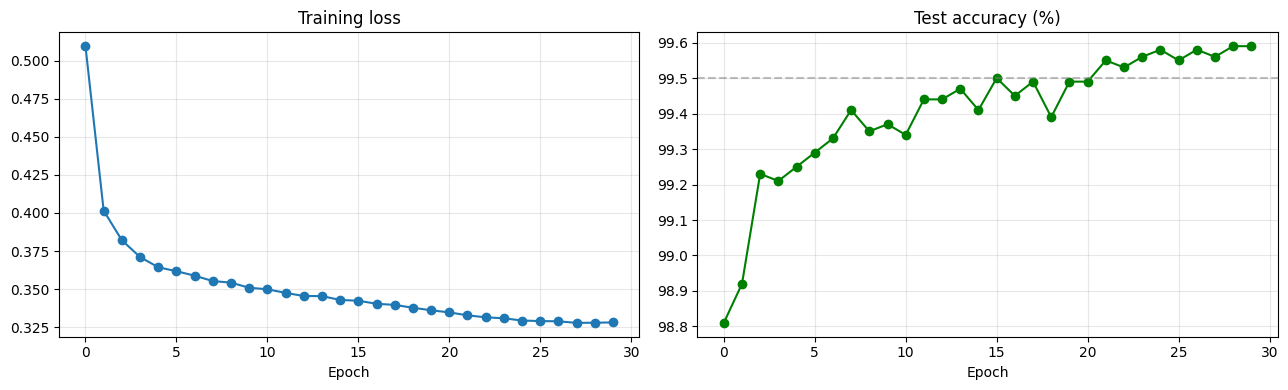

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(history["loss"], marker='o')
axes[0].set_title("Training loss"); axes[0].set_xlabel("Epoch"); axes[0].grid(alpha=0.3)
axes[1].plot(np.array(history["val_acc"]) * 100, marker='o', color='green')
axes[1].axhline(99.5, ls='--', color='gray', alpha=0.5)
axes[1].set_title("Test accuracy (%)"); axes[1].set_xlabel("Epoch"); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 9. Inspect the mistakes



Misclassified: 42 / 10000


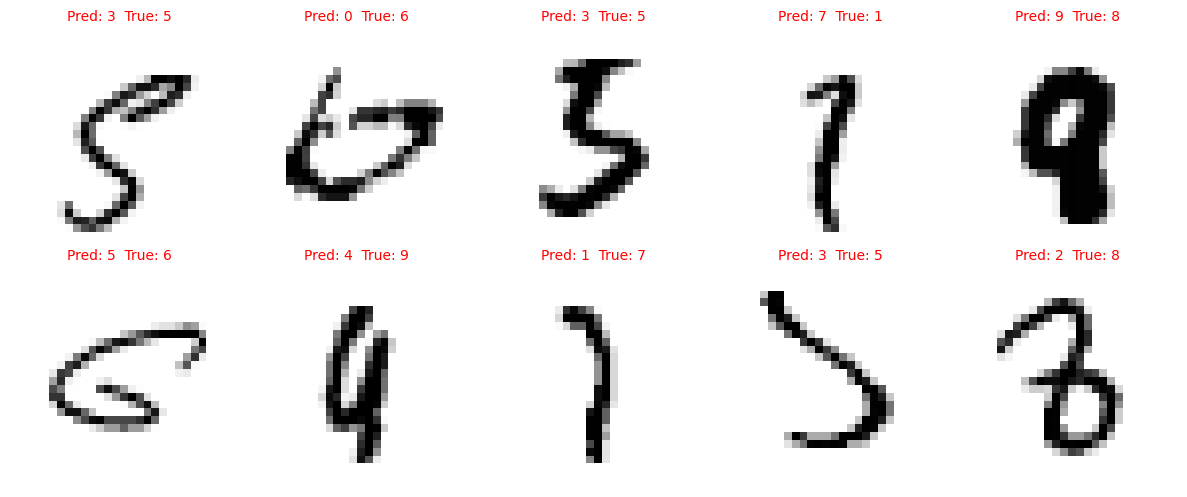

In [13]:
# Batched predictions on the test set
preds = np.concatenate([
    model.forward(X_test[i:i+512], training=False).argmax(1)
    for i in range(0, len(X_test), 512)
])
true = y_test.argmax(1)
wrong = np.where(preds != true)[0]
print(f"Misclassified: {len(wrong)} / {len(true)}")

n_show = min(10, len(wrong))
if n_show:
    fig, axes = plt.subplots(2, 5, figsize=(12, 5))
    for ax, idx in zip(axes.flat, wrong[:n_show]):
        ax.imshow(X_test_raw[idx].reshape(28, 28), cmap='binary')
        ax.set_title(f"Pred: {preds[idx]}  True: {true[idx]}", color='red', fontsize=10)
        ax.axis('off')
    for ax in axes.flat[n_show:]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

## 10. Optional: ensemble — the path toward 99.7%+

Single models on MNIST hit a ceiling around 99.5-99.6% because the remaining errors are near-ambiguous digits. Averaging the softmax outputs of several independently trained models (different seeds → different mistakes) reliably recovers another 0.1-0.2%. This is how the published 99.7-99.8% results are obtained (combined with richer augmentation).

**Warning:** this trains `n_models` full networks — budget hours of CPU time for the full architecture.

In [14]:
def train_ensemble(n_models=3, epochs=30):
    models = []
    for m in range(n_models):
        print(f"\n=== Model {m+1}/{n_models} ===")
        np.random.seed(100 + m)
        net = make_full_cnn()
        train(net, X_train, y_train, X_test, y_test,
              epochs=epochs, lr_max=2e-3, batch_size=128,
              augment=True, label_smoothing=0.05, weight_decay=1e-4,
              log_every=5)
        models.append(net)
    return models


def ensemble_accuracy(models, X, y, batch_size=512):
    correct = 0
    for i in range(0, len(X), batch_size):
        probs = None
        for net in models:
            logits = net.forward(X[i:i+batch_size], training=False)
            e = np.exp(logits - logits.max(axis=1, keepdims=True))
            p = e / e.sum(axis=1, keepdims=True)
            probs = p if probs is None else probs + p
        correct += (probs.argmax(1) == y[i:i+batch_size].argmax(1)).sum()
    return correct / len(X)

# Uncomment to run (expensive!):
# models = train_ensemble(n_models=3, epochs=30)
# print(f"Ensemble test accuracy: {ensemble_accuracy(models, X_test, y_test)*100:.2f}%")

## Going further

If you want to squeeze out every last error, in rough order of value:

1. **Elastic distortions** (Simard et al., 2003) — the classic MNIST augmentation. Random smooth displacement fields warp strokes the way real handwriting varies. This plus shifts is what took LeNet-style nets to ~99.6% single-model.
2. **Small random rotations (±10°) and scalings (±10%)** — easy to add with `scipy.ndimage` (preprocessing only; the network itself stays pure NumPy).
3. **Bigger ensemble (5-9 models)** with different architectures/seeds.
4. **Test-time augmentation** — average predictions over the original image plus a few shifted copies.
5. **More epochs** (60-100) with the cosine schedule stretched accordingly.
